In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df = pd.read_csv('mushrooms.csv')
df

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [26]:
X = pd.get_dummies(df.drop('class', axis=1),drop_first=True)
y = df['class']

### **Train/Test Split**

In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

### **Gradiant Boost classifier model with defalut parameter**

In [28]:
# Modelling 
from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier()
model.fit(X_train, y_train)

# Prediction
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

# Evalution
from sklearn.metrics import accuracy_score
print('Train accuracy:', accuracy_score(y_train, y_pred_train))
print('Test acuracy:', accuracy_score(y_test, y_pred_test))

from sklearn.model_selection import cross_val_score
scores = cross_val_score(model, X, y, cv=5)
print('Cross Validation Score:', scores.mean())

Train accuracy: 1.0
Test acuracy: 1.0
Cross Validation Score: 0.9192312239484653


#### **Identify best parameters for fradient boost model using Hyperparameter Tunning**

In [29]:
from sklearn.model_selection import GridSearchCV

#Model/Estomator
estimator = GradientBoostingClassifier()

# Paramaters grid
param_grid = {'n_estimators': [1,5,10,20],
             'learning_rate': [0.1,0.2,0.3,0.5,0.8,1]}

# gris search
grid = GridSearchCV(estimator, param_grid, cv=5, scoring='accuracy')

#fit the data
grid.fit(X_train, y_train)

# best parameters for AdaBoost model
print(grid.best_params_)

{'learning_rate': 0.8, 'n_estimators': 10}


#### **Feature Importance**

In [30]:
grid.best_estimator_.feature_importances_

array([2.61031387e-04, 3.06153768e-15, 4.93595285e-16, 0.00000000e+00,
       0.00000000e+00, 2.15735016e-03, 2.65301763e-18, 2.60829221e-16,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.72655470e-05,
       1.44345434e-03, 2.70933529e-02, 6.01141681e-05, 2.09335366e-03,
       4.97454211e-04, 0.00000000e+00, 6.22382095e-01, 1.60783391e-04,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 2.60768655e-02,
       2.89340328e-03, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
       0.00000000e+00, 3.88680984e-04, 1.69207727e-01, 0.00000000e+00,
       4.59278191e-03, 1.31083701e-02, 0.00000000e+00, 3.02152601e-05,
       0.00000000e+00, 0.00000000e+00, 8.54333311e-02, 0.00000000e+00,
       0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
      

In [31]:
feats = pd.DataFrame(index = X.columns,
                    data = grid.best_estimator_.feature_importances_,
                    columns = ['Importance'])

important_features = feats[feats['Importance']>0.01]

imp_features_list = feats[feats['Importance']>0.01].index.to_list()

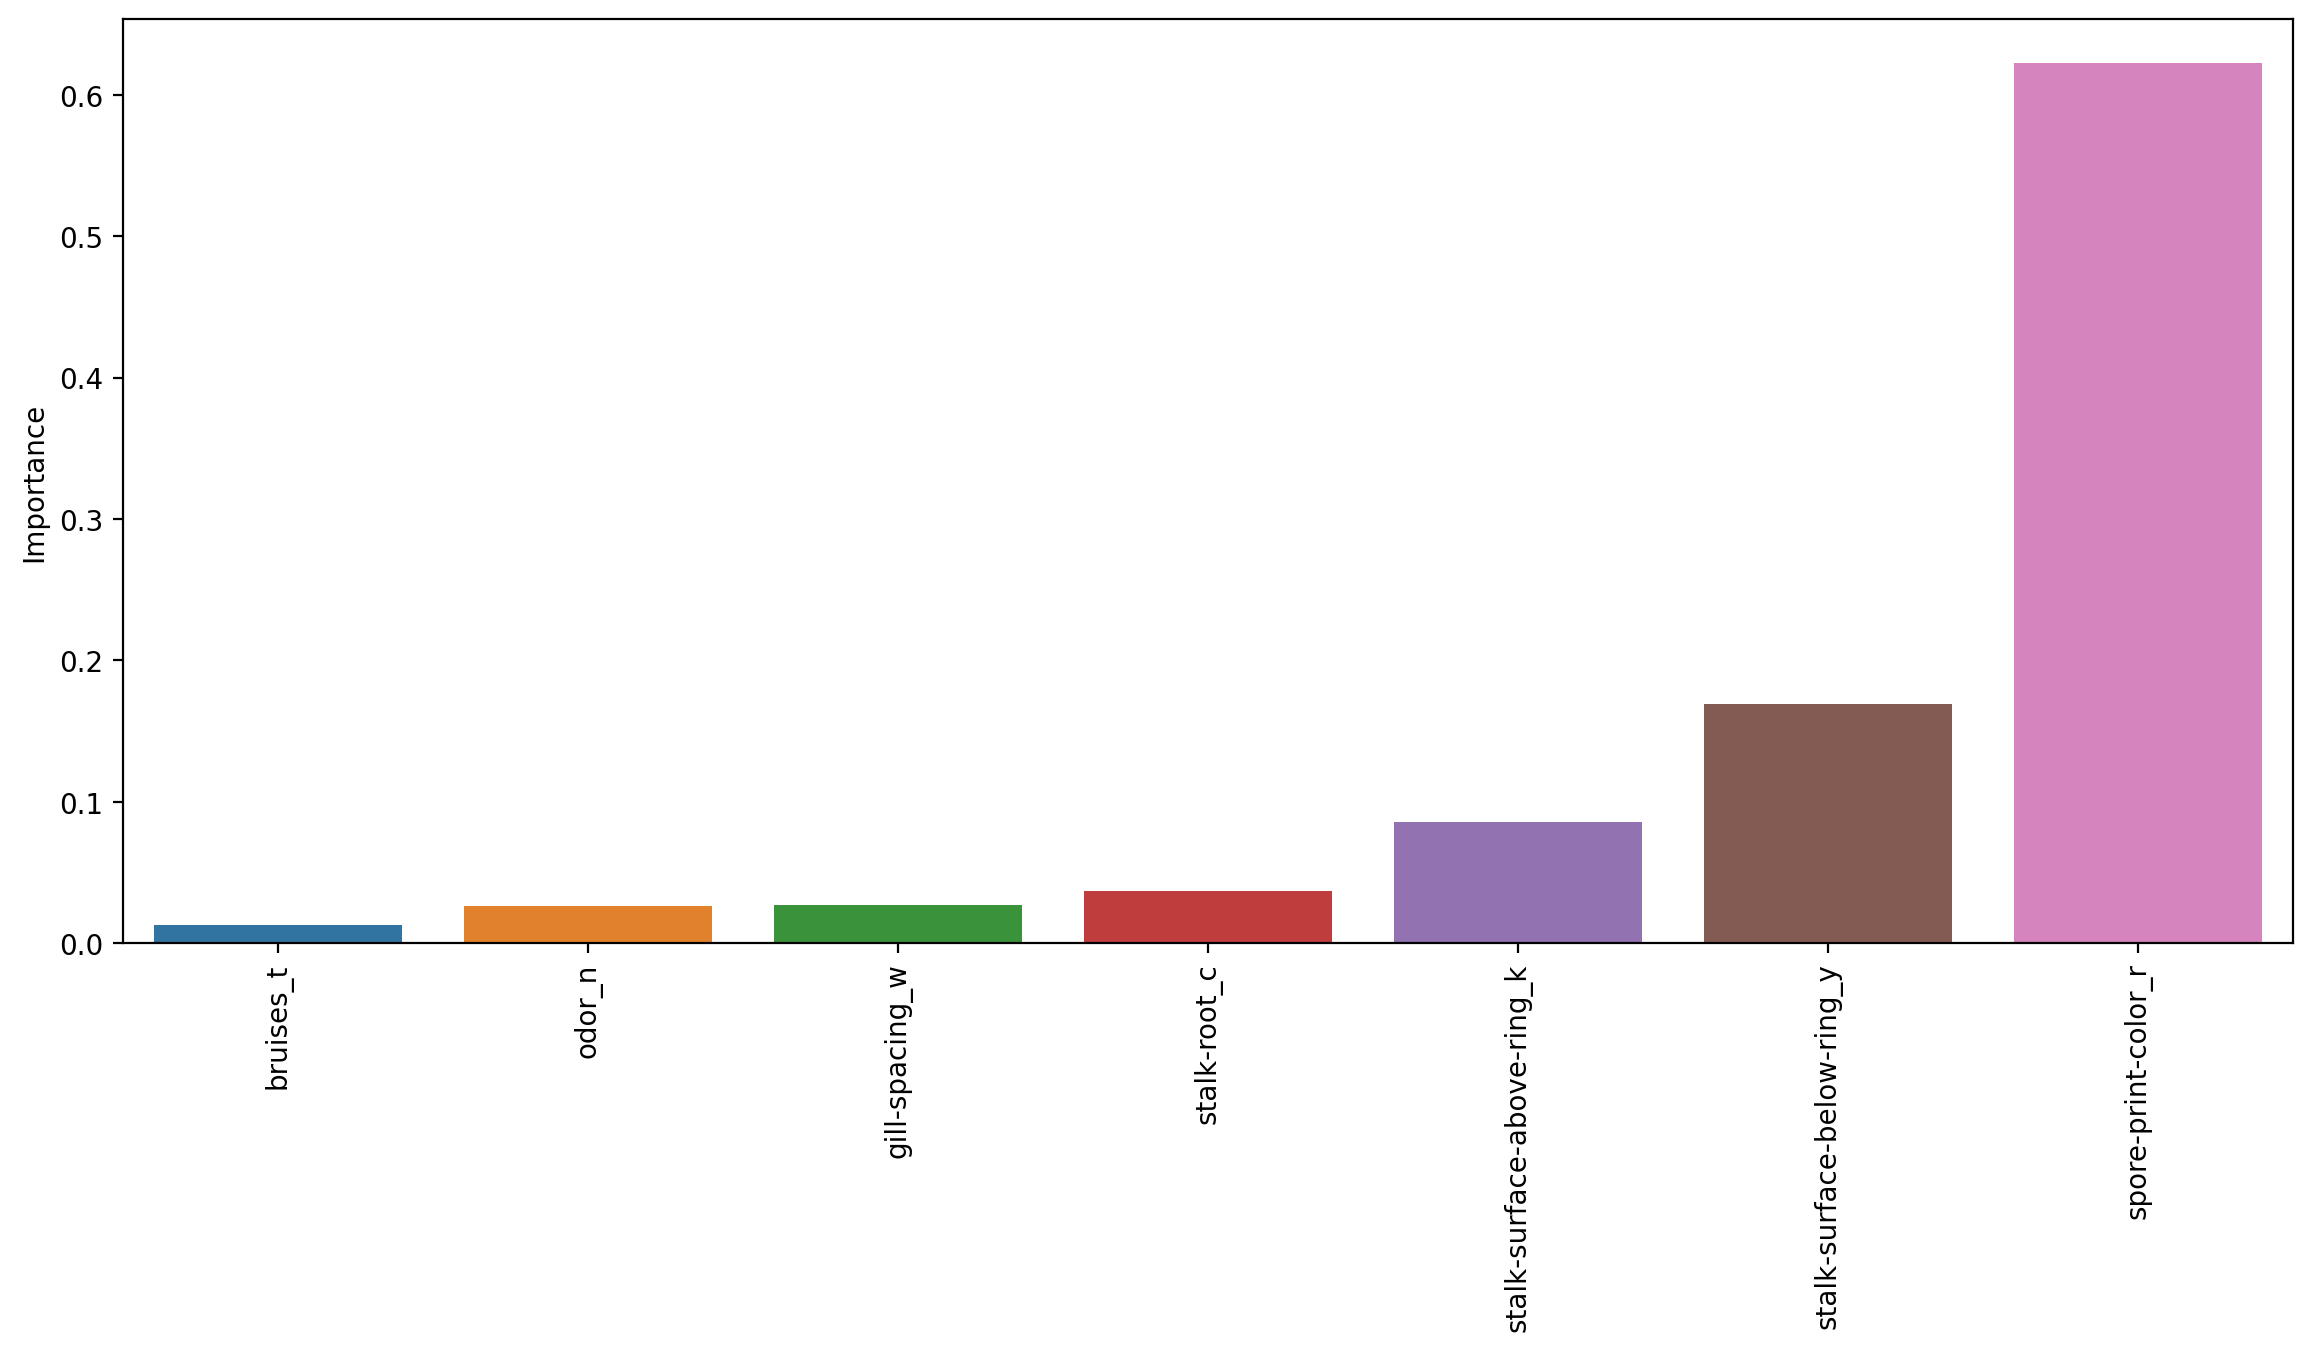

In [32]:
plt.figure(figsize=(14,6),dpi=200)

sns.barplot(data=important_features.sort_values('Importance'),
           x=important_features.index,
           y='Importance')
plt.xticks(rotation=90)
plt.show()

### **Rebild the GradientBoost with important feature & best Hyperparameters**

In [33]:
# Dropped unimportant
X_imp = X[imp_features_list]
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X_imp, y, test_size=0.2, random_state=10)

# Modelling
gb_bhp = GradientBoostingClassifier(n_estimators=10, learning_rate=0.8)
gb_bhp.fit(X_train, y_train)

# Prediction
ypred_train = gb_bhp.predict(X_train)
predictions = gb_bhp.predict(X_test)

# Evalutions
from sklearn.metrics import accuracy_score
print('Train accuracy:', accuracy_score(y_train, ypred_train))
print('Test accuracy:', accuracy_score(y_test, predictions))

scores = cross_val_score(gb_bhp, X_imp, y, cv=5)
print('Cross Validation Score:', scores.mean())

Train accuracy: 0.9987690413909832
Test accuracy: 1.0
Cross Validation Score: 0.9990147783251231


**Confusion Matrix**

In [34]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, predictions)

array([[861,   0],
       [  0, 764]], dtype=int64)

**Classification Report**

In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           e       1.00      1.00      1.00       861
           p       1.00      1.00      1.00       764

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625

